In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import subprocess
import sys
from pathlib import Path

package_dir = Path.cwd().resolve()
if package_dir.name == 'examples':
    package_dir = package_dir.parent
else:
    repo_candidate = Path('packages/visualization/calibrated-explanations-visualization-plotly').resolve()
    if repo_candidate.exists():
        package_dir = repo_candidate

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-e', str(package_dir)])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly>=5.18'])

import importlib
import ce_visualization_plotly
import ce_visualization_plotly.plugin as plotly_plugin

importlib.reload(plotly_plugin)
plotly_plugin.register_plotly_visualization_components()

# Plotly local factual bars

The default plot visually resembles CE's simple factual bar plot with `uncertainty=False`: it shows contribution bars only. Hover reveals the calibrated contribution interval and prediction interval metadata. Use `show_uncertainty=True` when visible uncertainty bars are desired.

This is a local factual plot, not a global explanation.

In [3]:
import numpy as np
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from calibrated_explanations import WrapCalibratedExplainer
import ce_visualization_plotly.plugin  # noqa: F401 - registers Plotly styles

## Classification

In [4]:
X_cls, y_cls = make_classification(
    n_samples=600,
    n_features=8,
    n_informative=5,
    n_redundant=0,
    random_state=7,
)
x_proper, x_temp, y_proper, y_temp = train_test_split(
    X_cls,
    y_cls,
    test_size=0.40,
    random_state=7,
    stratify=y_cls,
)
x_cal, X_query, y_cal, y_query = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=7,
    stratify=y_temp,
)

model = LogisticRegression(max_iter=1000, solver="liblinear", random_state=7)
explainer = WrapCalibratedExplainer(model)
explainer.fit(x_proper, y_proper)
assert explainer.fitted is True

explainer.calibrate(x_cal, y_cal)
assert explainer.calibrated is True

factual = explainer.explain_factual(X_query[:3])

c:\Users\loftuw\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: UserWarning: Cache backend fallback: using minimal in-package LRU/TTL implementation due to missing 'cachetools'
  return _bootstrap._gcd_import(name[level:], package, level)


In [10]:
factual[0].plot(style="plotly.local.factual_bars", show=True);

C:\Users\loftuw\Documents\Github\moffran-calibrated_explanations\calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


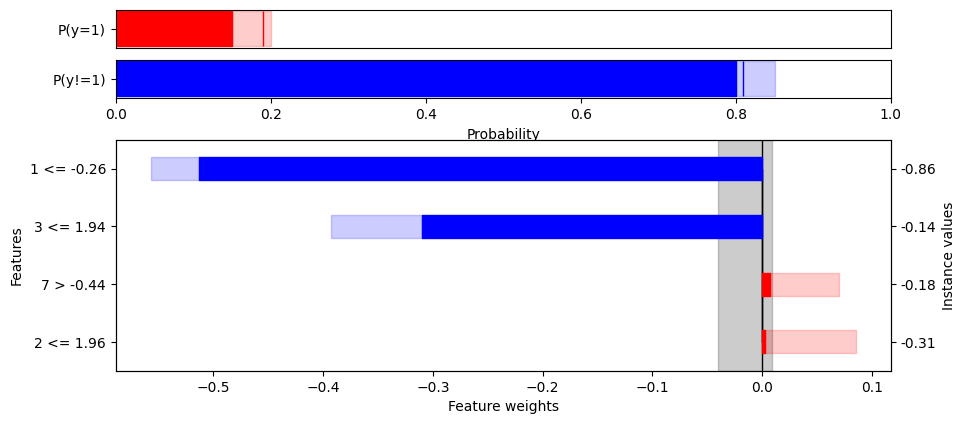

In [13]:
factual[0].plot(
    style="plotly.local.factual_bars",
    show=True,
    show_uncertainty=True,
);
factual[0].plot(uncertainty=True,
)

## Regression

In [7]:
X_reg, y_reg = make_regression(
    n_samples=600,
    n_features=8,
    n_informative=6,
    noise=8.0,
    random_state=11,
)
x_proper_reg, x_temp_reg, y_proper_reg, y_temp_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.40,
    random_state=11,
)
x_cal_reg, X_query_reg, y_cal_reg, y_query_reg = train_test_split(
    x_temp_reg,
    y_temp_reg,
    test_size=0.50,
    random_state=11,
)

reg_model = RandomForestRegressor(n_estimators=80, random_state=11)
reg_explainer = WrapCalibratedExplainer(reg_model)
reg_explainer.fit(x_proper_reg, y_proper_reg)
assert reg_explainer.fitted is True

reg_explainer.calibrate(x_cal_reg, y_cal_reg)
assert reg_explainer.calibrated is True

reg_factual = reg_explainer.explain_factual(
    X_query_reg[:3],
    low_high_percentiles=(10, 90),
)

In [8]:
reg_factual[0].plot(style="plotly.local.factual_bars", show=True)

PlotRenderResult(artifact={'artifact_type': 'plotly.local.factual_bars', 'artifact_version': '0.1.0', 'style': 'plotly.local.factual_bars', 'mode': 'regression', 'task': 'regression', 'prediction': {'value': -92.51986402735675, 'low': -138.86152376225223, 'high': -33.38992977973058, 'label': '1.0', 'mode': 'regression', 'task': 'regression'}, 'items': [{'id': 'rule-6', 'rank': 0, 'feature_index': 6, 'feature_name': '6', 'rule': '6 <= 0.16', 'instance_value': -1.2818038176315936, 'contribution': -152.88346078899045, 'contribution_low': -212.0133950366166, 'contribution_high': -106.54180105409496, 'interval_width': 105.47159398252164, 'crosses_zero': False, 'direction': 'negative', 'hover': 'Rule: 6 <= 0.16<br>Feature: 6<br>Feature index: 6<br>Current value: -1.2818038176315936<br>Contribution: -152.883<br>Contribution interval: [-212.013, -106.542]<br>Interval width: 105.472<br>Crosses zero: no<br>Prediction: -92.5199<br>Prediction interval: [-138.862, -33.3899]<br>Task: regression<br>M

## HTML export

In [9]:
factual[0].plot(
    style="plotly.local.factual_bars",
    show=False,
    path="local_factual_bars.html",
)

TypeError: calibrated_explanations.plotting.plot_probabilistic() got multiple values for keyword argument 'path'